### MNIST Digit Classification

- Handwritten digit classification using neural networks.
- Developed three different model versions with increasing architectural complexity.
- Compared model performance to understand the impact of network design choices on classification accuracy.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [3]:
import matplotlib.pyplot as plt

In [4]:
print(f"pytrorch version: {torch.__version__}, torchvision version: {torchvision.__version__}")

pytrorch version: 2.9.1+cu126, torchvision version: 0.24.1+cu126


In [5]:
train_data=torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data=torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
    
)

In [6]:
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [7]:
image.shape

torch.Size([1, 28, 28])

In [8]:
len(train_data.data),len(train_data.targets),len(test_data.data),len(test_data.targets)

(60000, 60000, 10000, 10000)

In [9]:
class_names=train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [10]:
print(f"image shape: {image.shape}")

image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '5')

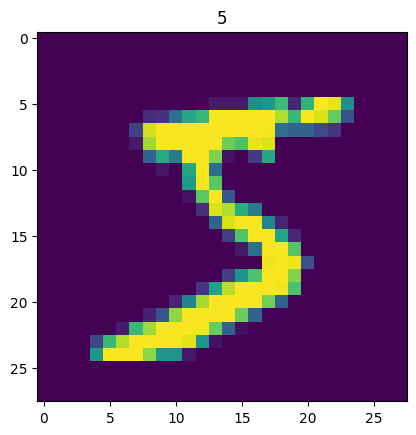

In [11]:
plt.imshow(image.squeeze())
plt.title(label)

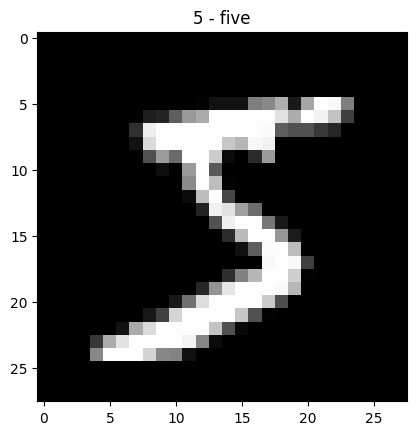

In [12]:
plt.imshow(image.squeeze(),cmap='gray')
plt.title(class_names[label]);

In [13]:
from torch.utils.data import DataLoader

In [14]:
BATCH_SIZE=32
train_dataloader=DataLoader(train_data,
   batch_size=BATCH_SIZE,
   shuffle=True                         
    
)
test_dataloader=DataLoader(test_data,
        batch_size=BATCH_SIZE,
        shuffle=False
        )



In [15]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [16]:
flatten_model=nn.Flatten()
x=train_features_batch.data[0]
output=flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [color_channel,height,width]")
print(f"Shape after flattening: {output.shape} -> [color_channels,height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channel,height,width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels,height*width]


In [17]:
class MNISTModelV0(nn.Module):
    def __init__(self,input_shape: int, hidden_units: int,output_shape: int):
        super().__init__()
        self.layer_stack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_shape)
        )
        
    def forward(self,x):
        return self.layer_stack(x)
    

In [18]:


model_0=MNISTModelV0(input_shape=784,
        hidden_units=10,
        output_shape=len(class_names)
        )

model_0.to("cpu")

MNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
import requests
from pathlib import Path

In [20]:
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
    
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)
        

helper_functions.py already exists, skipping download


In [21]:
from helper_functions import accuracy_fn

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


In [22]:
from timeit import default_timer as timer
def print_train_time(start:float,end:float,device:torch.device=None):
    total_time=end-start
    print(f"train time on {device}: {total_time:.3f} seconds")
    return total_time

In [23]:
from tqdm.auto import tqdm

torch.manual_seed=42
train_time_start_on_cpu=timer()

epochs=3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    
    train_loss=0
    
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        
        y_pred=model_0(X)
        loss=loss_fn(y_pred,y)
        train_loss += loss
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        
        if batch % 400 == 0:
            print(f"Looked at { batch*len(x)}/{len(train_dataloader.dataset)} samples ")
            
        
    train_loss /= len(train_dataloader)
    
    test_loss,test_acc = 0, 0
    
    model_0.eval()
        
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_0(X)
            
            test_loss += loss_fn (test_pred, y).item()
            
            test_acc += accuracy_fn (y_true = y, y_pred=test_pred.argmax(dim=1) )
            
            
        test_loss /= len(test_dataloader)
        
        test_acc /= len(test_dataloader)
        
    
    print(f"Train Loss : {train_loss:.5f} | Test Loss : {test_loss:.5f}, Test Accuracy : {test_acc:.2f}%\n")
        
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))
                
        
        
        
            
            
        

d:\Sonar rock vs mine prediction\sonar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples 
Looked at 400/60000 samples 
Looked at 800/60000 samples 
Looked at 1200/60000 samples 
Looked at 1600/60000 samples 


 33%|███▎      | 1/3 [00:11<00:22, 11.16s/it]

Train Loss : 0.40748 | Test Loss : 0.31954, Test Accuracy : 91.08%

Epoch: 1
-------
Looked at 0/60000 samples 
Looked at 400/60000 samples 
Looked at 800/60000 samples 
Looked at 1200/60000 samples 
Looked at 1600/60000 samples 


 67%|██████▋   | 2/3 [00:21<00:10, 10.87s/it]

Train Loss : 0.30813 | Test Loss : 0.28994, Test Accuracy : 91.87%

Epoch: 2
-------
Looked at 0/60000 samples 
Looked at 400/60000 samples 
Looked at 800/60000 samples 
Looked at 1200/60000 samples 
Looked at 1600/60000 samples 


100%|██████████| 3/3 [00:31<00:00, 10.44s/it]

Train Loss : 0.29646 | Test Loss : 0.28489, Test Accuracy : 91.81%

train time on cpu: 31.343 seconds


In [24]:
torch.manual_seed=42

def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    
    loss,acc=0,0
    model.eval()
    
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred=model(X)
            
            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
            
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return { "model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}
    
model_0_results=eval_model(model=model_0, data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)

model_0_results

{'model_name': 'MNISTModelV0',
 'model_loss': 0.2848864793777466,
 'model_acc': 91.81309904153355}

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
class MNISTModelV1(nn.Module):
    def __init__(self,input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_shape),
            nn.ReLU()
            
        )
    def forward(self,x: torch.Tensor):
        return self.layer_stack(x)

In [27]:
torch.manual_seed=42
model_1=MNISTModelV1(input_shape=784,
                     hidden_units=10,
                     output_shape=len(class_names)
        ).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [28]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)


In [29]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device):
    
    train_loss,train_acc=0,0
    model.to(device)
    model.train()
    
    for batch, (X,y) in enumerate(data_loader):
        X,y = X.to(device), y.to(device)
        
        
        y_pred = model(X)
        
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
    
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train Loss: {train_loss: .5f} | Train Accuracy: {train_acc: .2f}% ")
    
    
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device=device):
    
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    
    with torch.inference_mode():
        
        for X,y in data_loader:
            
            X,y = X.to(device), y.to(device)
            
            test_pred = model(X)
            
            test_loss += loss_fn(test_pred,y)
            test_acc += accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))
            
        
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)  

        
        print(f"Test loss: {test_loss: .5f} | Test accuracy: {test_acc: .2f}%\n")

In [30]:
torch.manual_seed=42

from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(data_loader=train_dataloader,
               model=model_1,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn
            )
    
    test_step(data_loader=test_dataloader,
              model=model_1,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn)
    
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)
        
        


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss:  1.12303 | Train Accuracy:  65.64% 


 33%|███▎      | 1/3 [00:16<00:33, 16.99s/it]

Test loss:  0.92559 | Test accuracy:  72.67%

Epoch: 1
-------
Train Loss:  0.90148 | Train Accuracy:  74.09% 


 67%|██████▋   | 2/3 [00:32<00:16, 16.35s/it]

Test loss:  0.87417 | Test accuracy:  74.60%

Epoch: 2
-------
Train Loss:  0.87794 | Train Accuracy:  74.86% 


100%|██████████| 3/3 [00:48<00:00, 16.27s/it]

Test loss:  0.86779 | Test accuracy:  75.13%

train time on cuda: 48.804 seconds


In [31]:
# torch.manual_seed=42
# model_1_results=eval_model(model=model_1,
#                            data_loader=test_dataloader,
#                            loss_fn=loss_fn,
#                            accuracy_fn=accuracy_fn,
#                            )

# model_1_results
# Note: This will give error cause 'eval_model()' not using device agnostic mode

In [32]:
torch.manual_seed=42

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device=device):
    
    loss,acc = 0, 0
    
    with torch.inference_mode():
        for X,y in data_loader:
            X,y = X.to(device), y.to(device)
            y_pred=model(X)
            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
            
            
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}
    

model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
                             loss_fn=loss_fn, accuracy_fn=accuracy_fn,
                             device=device)

model_1_results
        

{'model_name': 'MNISTModelV1',
 'model_loss': 0.8677870035171509,
 'model_acc': 75.12979233226837}

In [33]:
model_0_results

{'model_name': 'MNISTModelV0',
 'model_loss': 0.2848864793777466,
 'model_acc': 91.81309904153355}

In [34]:
class MNISTModelV2(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()
        self.block1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block2=nn.Sequential(
            nn.Conv2d(hidden_units,hidden_units,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units,hidden_units,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*6*6,
                      out_features=output_shape)
        )
    
    
    def forward(self, x:torch.Tensor):
        x=self.block1(x)
        
        x=self.block2(x)
        
        x=self.classifier(x)
        
        return x    
    
    
torch.manual_seed=42
model_2=MNISTModelV2(input_shape=1,
                     hidden_units=10,
                     output_shape=len(class_names)).to(device)
model_2

MNISTModelV2(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=360, out_features=10, bias=True)
  )
)

In [35]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [36]:
torch.manual_seed=42
from timeit import default_timer as timer
train_time_start_model_2=timer()

epochs=3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n----------")
    train_step(data_loader=train_dataloader,
               model=model_2,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
    test_step(data_loader=test_dataloader,
              model=model_2,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end_model_2=timer()

total_train_time_model_2=print_train_time(start=train_time_start_model_2,
                                          end=train_time_end_model_2,
                                          device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------
Train Loss:  0.44029 | Train Accuracy:  84.59% 


 33%|███▎      | 1/3 [00:18<00:37, 18.89s/it]

Test loss:  0.08178 | Test accuracy:  97.37%

Epoch: 1
----------
Train Loss:  0.07807 | Train Accuracy:  97.56% 


 67%|██████▋   | 2/3 [00:37<00:18, 18.78s/it]

Test loss:  0.05863 | Test accuracy:  98.14%

Epoch: 2
----------
Train Loss:  0.05973 | Train Accuracy:  98.19% 


100%|██████████| 3/3 [00:56<00:00, 18.85s/it]

Test loss:  0.06070 | Test accuracy:  98.05%

train time on cuda: 56.562 seconds


In [37]:
model_2_results=eval_model(model=model_2,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn)

model_2_results

{'model_name': 'MNISTModelV2',
 'model_loss': 0.06070149689912796,
 'model_acc': 98.05311501597444}

In [38]:
compare_results=pd.DataFrame([model_0_results,model_1_results,model_2_results])
compare_results

,model_name,model_loss,model_acc
0,MNISTModelV0,0.284886,91.813099
1,MNISTModelV1,0.867787,75.129792
2,MNISTModelV2,0.060701,98.053115


In [39]:
compare_results["training_time"]=[total_train_time_model_0,
                                  total_train_time_model_1,
                                  total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,training_time
0,MNISTModelV0,0.284886,91.813099,31.342559
1,MNISTModelV1,0.867787,75.129792,48.804451
2,MNISTModelV2,0.060701,98.053115,56.562471


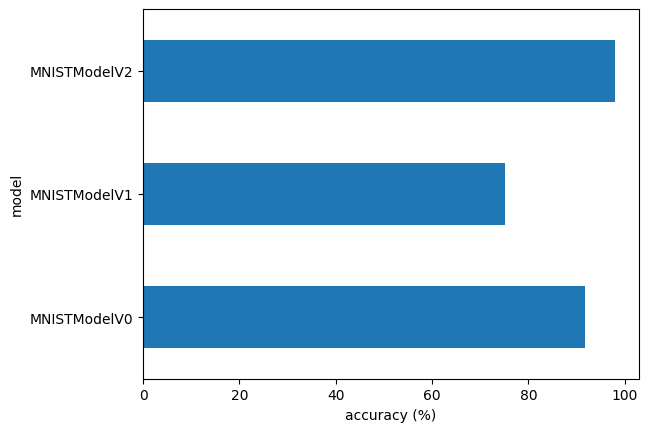

In [40]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");